In [ ]:
!pip install -q xgboost shap streamlit plotly joblib

In [ ]:
import pandas as pd
import numpy as np
import random
import warnings
import joblib

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [ ]:
np.random.seed(42)
random.seed(42)

N = 100000

data = pd.DataFrame({
    "transaction_id": range(1, N + 1),

    "amount": np.random.lognormal(
        mean=np.log(1500),
        sigma=1.0,
        size=N
    ),

    "hour": np.random.randint(0, 24, N),

    "account_age_days": np.random.randint(1, 2000, N),

    "transactions_last_10min": np.random.poisson(1.5, N),

    "transactions_last_1hour": np.random.poisson(4, N),

    "failed_attempts": np.random.poisson(0.5, N),

    "device_age_days": np.random.randint(1, 1000, N),

    "is_new_device": np.random.binomial(1, 0.15, N),

    "distance_from_last_transaction": np.random.exponential(
        scale=20,
        size=N
    ),

    "previous_amount": np.random.lognormal(
        mean=np.log(1200),
        sigma=0.8,
        size=N
    ),

    "merchant_risk": np.random.uniform(0, 1, N),

    "location_risk": np.random.uniform(0, 1, N)
})

In [ ]:
fraud_probability = (
    0.01
    + 0.08 * (data["amount"] > 10000)
    + 0.10 * (data["transactions_last_10min"] > 5)
    + 0.07 * (data["transactions_last_1hour"] > 15)
    + 0.08 * (data["failed_attempts"] > 3)
    + 0.08 * data["is_new_device"]
    + 0.08 * (data["distance_from_last_transaction"] > 200)
    + 0.10 * (data["merchant_risk"] > 0.8)
    + 0.08 * (data["location_risk"] > 0.8)
    + 0.08 * (
        data["amount"] >
        3 * data["previous_amount"]
    )
)

fraud_probability = np.clip(
    fraud_probability,
    0,
    0.95
)

data["is_fraud"] = np.random.binomial(
    1,
    fraud_probability
)

In [ ]:
print(data["is_fraud"].value_counts())
print(data["is_fraud"].value_counts(normalize=True))

is_fraud
0    91938
1     8062
Name: count, dtype: int64
is_fraud
0    0.91938
1    0.08062
Name: proportion, dtype: float64


In [ ]:
data["amount_ratio"] = (
    data["amount"] /
    (data["previous_amount"] + 1)
)

data["amount_deviation"] = abs(
    data["amount"] -
    data["previous_amount"]
)

data["velocity_10min"] = (
    data["transactions_last_10min"] / 10
)

data["velocity_1hour"] = (
    data["transactions_last_1hour"] / 60
)

data["night_transaction"] = (
    (data["hour"] < 6) |
    (data["hour"] >= 23)
).astype(int)

data["high_velocity"] = (
    data["transactions_last_10min"] > 5
).astype(int)

data["high_amount"] = (
    data["amount"] > 10000
).astype(int)

data["location_anomaly"] = (
    data["distance_from_last_transaction"] > 200
).astype(int)

In [ ]:
features = [
    "amount",
    "hour",
    "account_age_days",
    "transactions_last_10min",
    "transactions_last_1hour",
    "failed_attempts",
    "device_age_days",
    "is_new_device",
    "distance_from_last_transaction",
    "previous_amount",
    "merchant_risk",
    "location_risk",
    "amount_ratio",
    "amount_deviation",
    "velocity_10min",
    "velocity_1hour",
    "night_transaction",
    "high_velocity",
    "high_amount",
    "location_anomaly"
]

X = data[features]
y = data["is_fraud"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (80000, 20)
Testing: (20000, 20)


In [ ]:
fraud_count = y_train.sum()
normal_count = len(y_train) - fraud_count

scale_pos_weight = normal_count / fraud_count

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 11.4031007751938


In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.08, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_probability))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7241
ROC-AUC: 0.7359390004323675
Precision: 0.1584470094438615
Recall: 0.5620347394540943
F1 Score: 0.24720327421555252

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.74      0.83     18388
           1       0.16      0.56      0.25      1612

    accuracy                           0.72     20000
   macro avg       0.55      0.65      0.54     20000
weighted avg       0.89      0.72      0.78     20000



In [ ]:
print(confusion_matrix(y_test, y_pred))

[[13576  4812]
 [  706   906]]


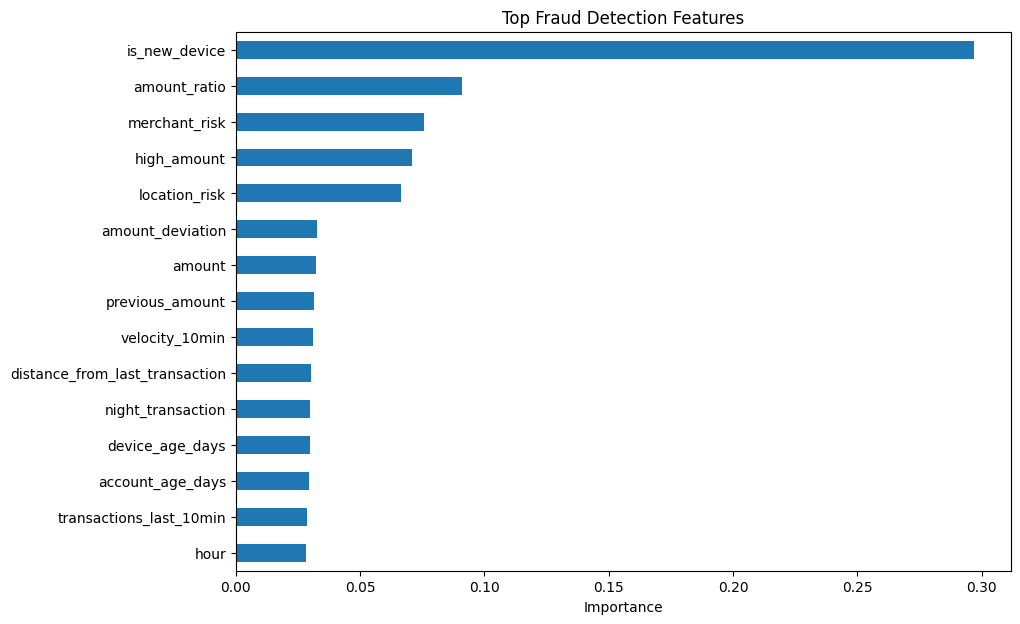

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))

importance.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top Fraud Detection Features")
plt.xlabel("Importance")
plt.show()

In [ ]:
def calculate_risk_score(probability):
    return round(probability * 100, 2)

In [ ]:
def risk_status(score):

    if score < 30:
        return "LOW RISK"

    elif score < 70:
        return "MEDIUM RISK"

    else:
        return "HIGH RISK"

In [ ]:
def generate_reasons(transaction):

    reasons = []

    if transaction["amount"] > 10000:
        reasons.append("Unusually high transaction amount")

    if transaction["amount_ratio"] > 3:
        reasons.append("Amount is much higher than previous transaction")

    if transaction["is_new_device"] == 1:
        reasons.append("New device detected")

    if transaction["transactions_last_10min"] > 5:
        reasons.append("High transaction velocity")

    if transaction["transactions_last_1hour"] > 15:
        reasons.append("Unusual number of transactions in last hour")

    if transaction["failed_attempts"] > 3:
        reasons.append("Multiple failed attempts")

    if transaction["distance_from_last_transaction"] > 200:
        reasons.append("Unusual location change")

    if transaction["merchant_risk"] > 0.8:
        reasons.append("High-risk merchant")

    if transaction["location_risk"] > 0.8:
        reasons.append("High-risk location")

    if transaction["night_transaction"] == 1:
        reasons.append("Unusual transaction time")

    if len(reasons) == 0:
        reasons.append("No major anomalies detected")

    return reasons

In [ ]:
def predict_transaction(transaction):

    transaction_df = pd.DataFrame([transaction])

    transaction_df["amount_ratio"] = (
        transaction_df["amount"] /
        (transaction_df["previous_amount"] + 1)
    )

    transaction_df["amount_deviation"] = abs(
        transaction_df["amount"] -
        transaction_df["previous_amount"]
    )

    transaction_df["velocity_10min"] = (
        transaction_df["transactions_last_10min"] / 10
    )

    transaction_df["velocity_1hour"] = (
        transaction_df["transactions_last_1hour"] / 60
    )

    transaction_df["night_transaction"] = (
        (transaction_df["hour"] < 6) |
        (transaction_df["hour"] >= 23)
    ).astype(int)

    transaction_df["high_velocity"] = (
        transaction_df["transactions_last_10min"] > 5
    ).astype(int)

    transaction_df["high_amount"] = (
        transaction_df["amount"] > 10000
    ).astype(int)

    transaction_df["location_anomaly"] = (
        transaction_df["distance_from_last_transaction"] > 200
    ).astype(int)

    X_transaction = transaction_df[features]

    probability = model.predict_proba(
        X_transaction
    )[0][1]

    score = calculate_risk_score(probability)

    status = risk_status(score)

    reasons = generate_reasons(
        transaction_df.iloc[0]
    )

    return {
        "fraud_probability": round(probability * 100, 2),
        "risk_score": score,
        "status": status,
        "reasons": reasons
    }

In [ ]:
transaction = {
    "amount": 50000,
    "hour": 2,
    "account_age_days": 100,
    "transactions_last_10min": 8,
    "transactions_last_1hour": 20,
    "failed_attempts": 5,
    "device_age_days": 1,
    "is_new_device": 1,
    "distance_from_last_transaction": 500,
    "previous_amount": 2000,
    "merchant_risk": 0.9,
    "location_risk": 0.9
}

result = predict_transaction(transaction)

print("Fraud Probability:", result["fraud_probability"], "%")
print("Risk Score:", result["risk_score"])
print("Status:", result["status"])

print("\nReasons:")

for reason in result["reasons"]:
    print("•", reason)

Fraud Probability: 13.46 %
Risk Score: 13.46
Status: LOW RISK

Reasons:
• Unusually high transaction amount
• Amount is much higher than previous transaction
• New device detected
• High transaction velocity
• Unusual number of transactions in last hour
• Multiple failed attempts
• Unusual location change
• High-risk merchant
• High-risk location
• Unusual transaction time


In [ ]:
joblib.dump(model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [ ]:
joblib.dump(features, "features.pkl")

['features.pkl']